# Question 1: Lagrange and Cubic Spline Interpolation

Given the data points $(6,2)$, $(5,5)$, $(4,8)$, $(3,5)$, $(2,3)$, $(1,1)$, we interpolate using **Lagrange polynomial interpolation** and **cubic spline interpolation**, and derive the exact formulas.

In [18]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, lagrange

# Given data points (x, y)
x_data = np.array([6, 5, 4, 3, 2, 1], dtype=float)
y_data = np.array([2, 5, 8, 5, 3, 1], dtype=float)

print("Data points:")
for xi, yi in zip(x_data, y_data):
    print(f"  ({xi:.0f}, {yi:.0f})")

Data points:
  (6, 2)
  (5, 5)
  (4, 8)
  (3, 5)
  (2, 3)
  (1, 1)


## 1.1 Lagrange Interpolation

The Lagrange interpolating polynomial of degree $n-1$ passing through $n$ points is:

$$L(x) = \sum_{i=0}^{n-1} y_i \prod_{\substack{j=0 \\ j \neq i}}^{n-1} \frac{x - x_j}{x_i - x_j}$$

In [22]:
# lagrange
poly_lagrange = lagrange(x_data, y_data)
print("Exact Lagrange interpolating polynomial:")
print(poly_lagrange)

print("\nPolynomial coefficients (highest degree first):")
print(poly_lagrange.coef)

Exact Lagrange interpolating polynomial:
       5         4         3         2
0.175 x - 2.958 x + 18.37 x - 52.04 x + 68.45 x - 31

Polynomial coefficients (highest degree first):
[  0.175       -2.95833333  18.375      -52.04166667  68.45
 -31.        ]


## 1.2 Cubic Spline Interpolation

A **natural cubic spline** is a piecewise cubic polynomial $S_i(x)$ on each interval $[x_i, x_{i+1}]$ such that the function and its first two derivatives are continuous at all knots. For spline interpolation, the $x$-values must be in strictly increasing order.

In [20]:
# Sort points in increasing x order (required for cubic spline)
sort_idx = np.argsort(x_data)
x_sorted = x_data[sort_idx]
y_sorted = y_data[sort_idx]

cs = CubicSpline(x_sorted, y_sorted)

print("Exact cubic spline (piecewise polynomials):")
print("S(x) = \n")
for i in range(len(x_sorted) - 1):
    a, b, c, d = cs.c[:, i]
    print(f"  On [{x_sorted[i]:.0f}, {x_sorted[i+1]:.0f}]:")
    print(f"    S_{i}(x) = {a:.6f}·x³ + {b:.6f}·x² + {c:.6f}·x + {d:.6f}")
    print()

Exact cubic spline (piecewise polynomials):
S(x) = 

  On [1, 2]:
    S_0(x) = 0.666667·x³ + -2.000000·x² + 3.333333·x + 1.000000

  On [2, 3]:
    S_1(x) = 0.666667·x³ + 0.000000·x² + 1.333333·x + 3.000000

  On [3, 4]:
    S_2(x) = -2.333333·x³ + 2.000000·x² + 3.333333·x + 5.000000

  On [4, 5]:
    S_3(x) = 1.666667·x³ + -5.000000·x² + 0.333333·x + 8.000000

  On [5, 6]:
    S_4(x) = 1.666667·x³ + 0.000000·x² + -4.666667·x + 5.000000



## 1.3 Visualization and Comparison

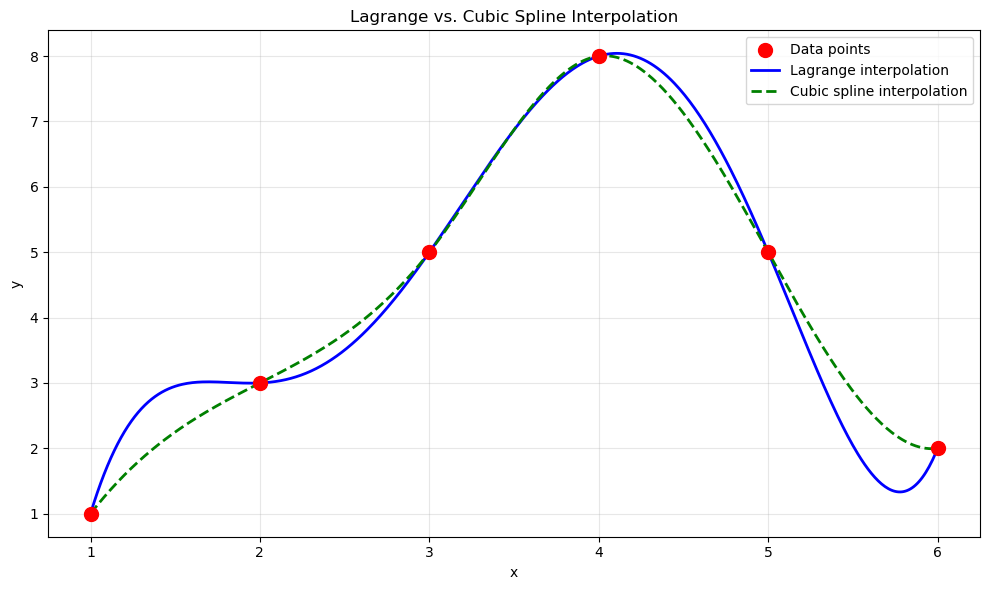

In [21]:
x_fine = np.linspace(x_sorted.min(), x_sorted.max(), 500)
y_lagrange = poly_lagrange(x_fine)
y_spline = cs(x_fine)

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='red', s=100, zorder=5, label='Data points')
plt.plot(x_fine, y_lagrange, 'b-', linewidth=2, label='Lagrange interpolation')
plt.plot(x_fine, y_spline, 'g--', linewidth=2, label='Cubic spline interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrange vs. Cubic Spline Interpolation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

| Method | Formula Type | Degree / Form |
|--------|-------------|---------------|
| **Lagrange** | Single polynomial | Degree 5: $L(x) = 0.175x^5 - 2.958x^4 + 18.375x^3 - 52.042x^2 + 68.45x - 31$ |
| **Cubic Spline** | Piecewise cubics | 5 cubic pieces on intervals $[1,2], [2,3], [3,4], [4,5], [5,6]$ |

- The **Lagrange polynomial** is a single degree-5 polynomial that passes exactly through all 6 points.
- The **cubic spline** uses 5 piecewise cubic polynomials with continuous first and second derivatives at interior knots.
- Both interpolants agree at the data points, but differ between them: the Lagrange polynomial may exhibit larger oscillations (Runge-like behavior at boundaries), while the spline tends to be smoother locally.